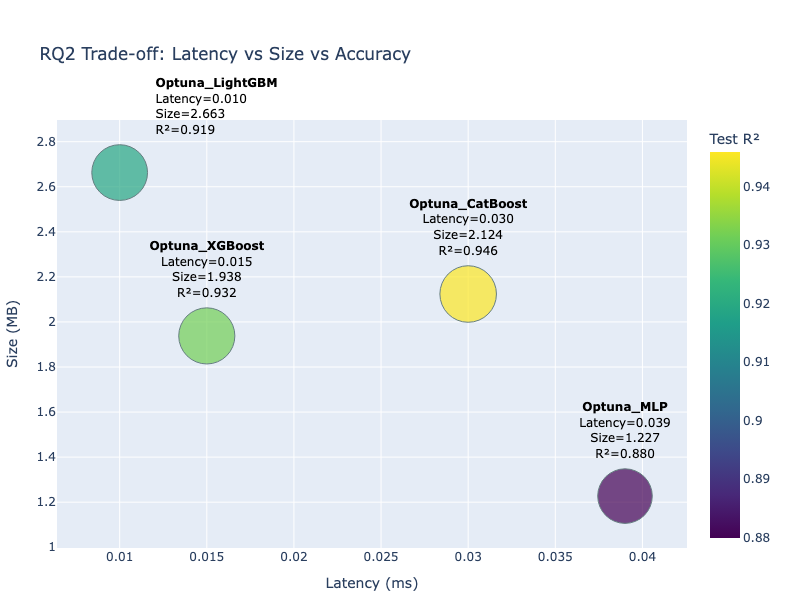

In [12]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("phase2_comparison_results.csv")
df["callout"] = df.apply(
    lambda r: (
        f"<b>{r.model}</b><br>"
        f"Latency={r.latency_ms:.3f}<br>"
        f"Size={r.model_size_mb:.3f}<br>"
        f"R²={r.test_r2:.3f}"
    ), axis=1
)

# decide per-point text positions
textpos = [
    "top right" if m=="Optuna_LightGBM" else "top center"
    for m in df["model"]
]

fig = px.scatter(
    df,
    x="latency_ms", y="model_size_mb",
    color="test_r2", size="test_r2",
    color_continuous_scale="viridis",
    labels={"latency_ms":"Latency (ms)", "model_size_mb":"Size (MB)", "test_r2":"Test R²"},
    title="RQ2 Trade-off: Latency vs Size vs Accuracy",
    size_max=40
)

# draw markers + callouts, no hover, no clipping
fig.update_traces(
    mode="markers+text",
    text=df["callout"],
    textposition=textpos,
    textfont=dict(size=12, color="black"),
    hoverinfo="skip",
    marker=dict(opacity=0.7, line=dict(width=1, color="DarkSlateGrey")),
    cliponaxis=False
)

# extra top margin so nothing gets cut off
fig.update_layout(
    width=800, height=600,
    margin=dict(l=30, r=30, t=120, b=30),
    legend_title_text="Test R²"
)

fig.show()